# ***This is the implemented Linear regression model for the Validation Dataset***

In [41]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from itertools import product
import datetime
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import gaussian_kde

In [42]:
# Load the dataset
Cars_df = pd.read_csv('Validation.csv')

In [43]:
# Drop rows with any missing values
data_frame = Cars_df.dropna()

In [44]:
data_frame = pd.read_csv('Validation.csv')


def convert_price_to_number(price_str):
    # Remove commas and convert to float
    return float(price_str.replace(',', ''))

# Apply the function to the 'Price' column
data_frame['Price'] = data_frame['Price'].apply(convert_price_to_number)
# Applying log transformation to the 'Price' column to reduce skewness
data_frame['Log_Price'] = np.log1p(data_frame['Price'])

filtered_file_path = 'Validation_Filtered.csv'
data_frame.to_csv(filtered_file_path, index=False)

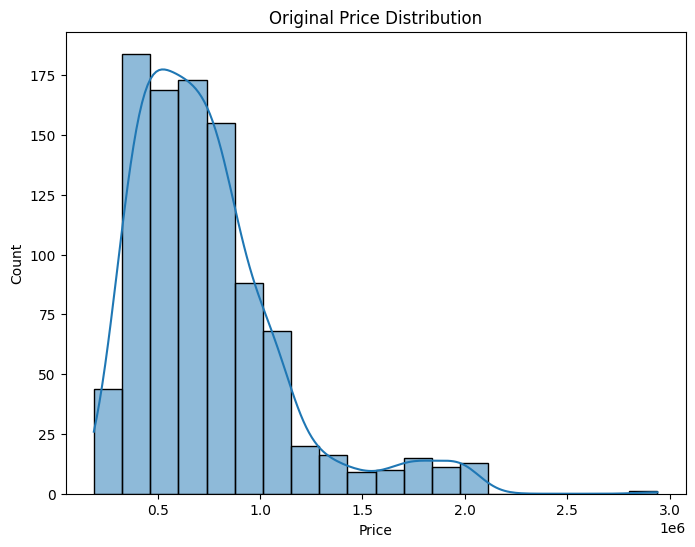

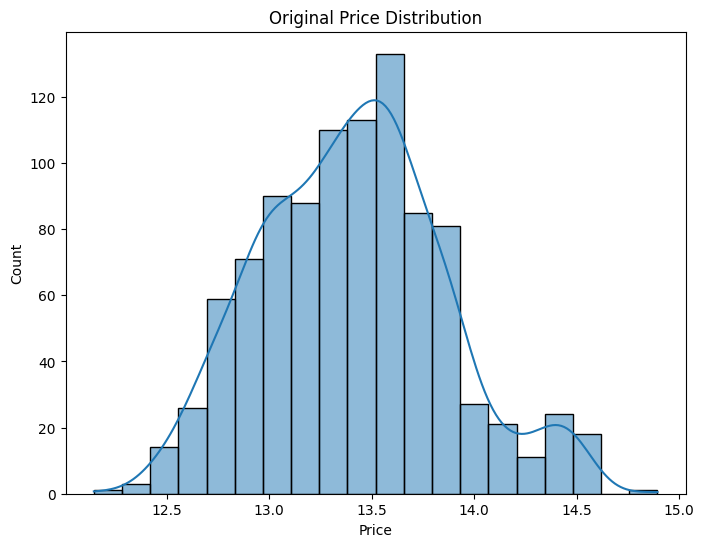

In [45]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')

plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Log_Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')


plt.show()

In [46]:
label_encoder = LabelEncoder()

data_frame['Transmission ID'] = label_encoder.fit_transform(data_frame['Transmission'])
Transmission = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [47]:
data_frame['Power'] = data_frame['Max Power']
# Convert the attribute to a numeric type
data_frame['Power'] = pd.to_numeric(data_frame['Power'], errors='coerce')

In [48]:
data_frame['Price'] = pd.to_numeric(data_frame['Price'], errors='coerce')

In [49]:
Aim_Price = data_frame["Log_Price"]
data_frame = data_frame.drop(["Log_Price"],axis=1)
data_frame["Aim_Price"]= Aim_Price
data_frame.to_csv("Validation_Final.csv")

In [50]:
x = data_frame[['Year','Seating Capacity', 'Transmission ID','Power']]
y = data_frame['Aim_Price']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [52]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [53]:
predictions = model.predict(x_test)

In [56]:
print("MSE : " , metrics.mean_squared_error(y_test, predictions))
print("RMSE : " ,np.sqrt(metrics.mean_squared_error(y_test, predictions)))
r2_score = model.score(x_test,y_test)
print("R2 Score % : ",r2_score*100,'%')
print("R2 Score : ",r2_score)

MSE :  0.028941615189817475
RMSE :  0.17012235358652159
R2 Score % :  86.3188521410985 %
R2 Score :  0.863188521410985
